## インデックスETFの分析を行う：

In [1]:
import pandas as pd
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as plt
import datetime
import seaborn as sns 
from kazustat import YFinanceAnalysis
import warnings 
from sklearn.preprocessing import StandardScaler

In [8]:
 # loading: 

growthetf = yf.download("2516.T", start="2020-01-01", end="2026-12-31")
dat = yf.Ticker("2516.T")

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_54108/1828135239.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  growthetf = yf.download("2516.T", start="2020-01-01", end="2026-12-31")
[*********************100%***********************]  1 of 1 completed


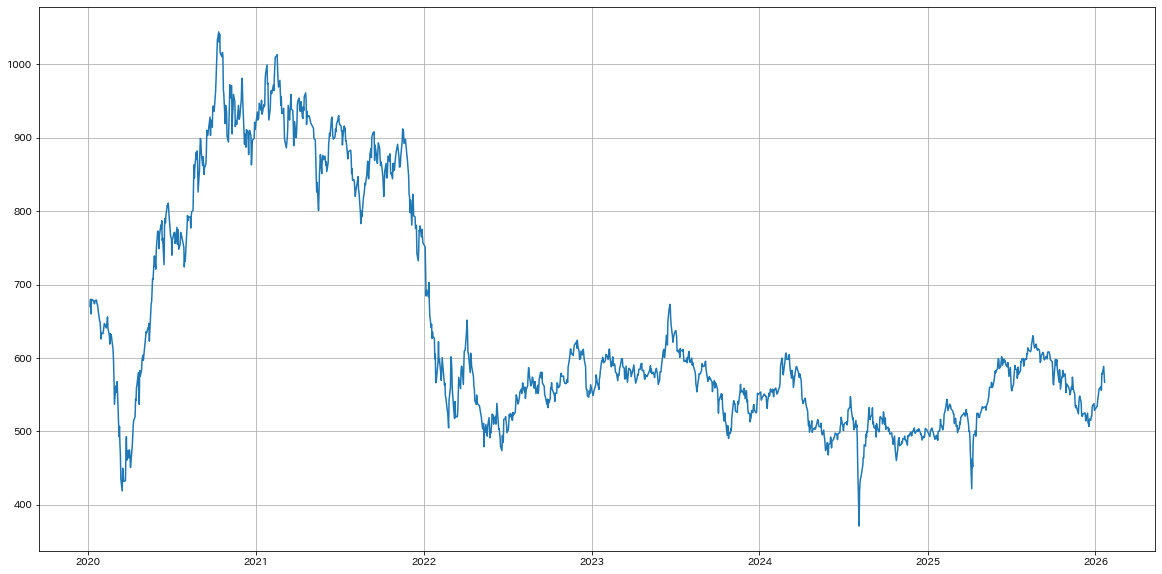

In [4]:
sf = growthetf.reset_index().copy()
sf.columns = ['Date', "Close_SB", "High_SB", "Low_SB", "Open_SB", "Volume_SB"]
plt.figure(figsize=(20,10))
plt.plot(sf['Date'],sf["Close_SB"], label="Growth ETF Close Price")
plt.grid()
plt.show()

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_54108/3400106514.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.keys()), period="2y")["Close"]
[*********************100%***********************]  5 of 5 completed

1 Failed download:
['^TPX']: YFPricesMissingError('possibly delisted; no price data found  (period=2y)')


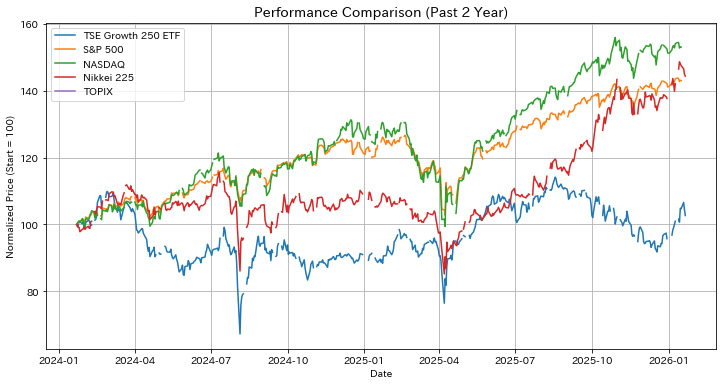

--- Correlation Matrix ---
Ticker              TSE Growth 250 ETF   S&P 500    NASDAQ  Nikkei 225  TOPIX
Ticker                                                                       
TSE Growth 250 ETF            1.000000  0.354754  0.380916    0.369129    NaN
S&P 500                       0.354754  1.000000  0.993207    0.804658    NaN
NASDAQ                        0.380916  0.993207  1.000000    0.841492    NaN
Nikkei 225                    0.369129  0.804658  0.841492    1.000000    NaN
TOPIX                              NaN       NaN       NaN         NaN    NaN


In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 取得したいティッカーのリスト
tickers = {
    "^N225": "Nikkei 225",
    "^TPX": "TOPIX",
    "2516.T": "TSE Growth 250 ETF",
    "^IXIC": "NASDAQ",
    "^GSPC": "S&P 500"
}

# 2. データのダウンロード (直近1年間)
data = yf.download(list(tickers.keys()), period="2y")["Close"]

# 3. カラム名を分かりやすく変更
data.rename(columns=tickers, inplace=True)

# 4. 分析：開始時点を100として正規化（パフォーマンス比較）
normalized_data = (data / data.iloc[0]) * 100

# 5. 可視化
plt.figure(figsize=(12, 6))
for column in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[column], label=column)

plt.title("Performance Comparison (Past 2 Year)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()

# 6. 相関関係の確認
print("--- Correlation Matrix ---")
print(data.corr())

In [14]:
dat.info


{'companyOfficers': [],
 'executiveTeam': [],
 'maxAge': 86400,
 'priceHint': 2,
 'previousClose': 576.6,
 'open': 564.1,
 'dayLow': 562.7,
 'dayHigh': 571.0,
 'regularMarketPreviousClose': 576.6,
 'regularMarketOpen': 564.1,
 'regularMarketDayLow': 562.7,
 'regularMarketDayHigh': 571.0,
 'trailingPE': 23.393236,
 'volume': 1296100,
 'regularMarketVolume': 1296100,
 'averageVolume': 811943,
 'averageVolume10days': 818954,
 'averageDailyVolume10Day': 818954,
 'bid': 567.0,
 'ask': 568.0,
 'bidSize': 0,
 'askSize': 0,
 'yield': 0.0,
 'totalAssets': 12074999808,
 'fiftyTwoWeekLow': 416.4,
 'fiftyTwoWeekHigh': 632.0,
 'allTimeHigh': 1049.0,
 'allTimeLow': 371.2,
 'fiftyDayAverage': 537.82,
 'twoHundredDayAverage': 568.854,
 'navPrice': 593.0,
 'currency': 'JPY',
 'tradeable': False,
 'ytdReturn': 5.73123,
 'beta3Year': 1.35,
 'fundFamily': 'Simplex Asset Management',
 'fundInceptionDate': 1517356800,
 'legalType': 'Exchange Traded Fund',
 'threeYearAverageReturn': 0.0104757,
 'fiveYearAver

In [15]:
spy = yf.Ticker('2516.T').funds_data
spy.description
spy.top_holdings

,Name,Holding Percent
Symbol,,
2160.T,GNI Group Ltd,0.043418
141A.T,Trial Holdings Inc,0.040247
4592.T,SanBio Co Ltd,0.033015
4478.T,Freee KK Ordinary Shares,0.028306
290A.T,Synspective Inc,0.023167
9166.T,Genda Inc,0.019233
215A.T,Timee Inc,0.018351
7806.T,MTG Co Ltd Ordinary Shares,0.016529
247A.T,Ai Robotics Inc,0.015760


## 単純に時系列モデル試してみるか